# Foundations of Machine learning

Problem Set 1

Emily Fu

## 1. Load the iris data set, using the seaborn package:

In [1]:
# importing packages and methods

# for the dataset
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# splitting data, cross-validation, and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve, cross_val_score

# classification algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# accuracy and stuff
from sklearn import metrics

# plotting 
import matplotlib.pyplot as plt
from seaborn import heatmap

# random seed
import numpy as np

In [10]:
# setting parameters

# set seed
seed = 420

# number of folds for cross-validation
k_folds = 5

# how many neighbours for KNN
n_neighbours = 3

# define the parameter grid (possible values for n_neighbors)
param_grid = {'knn__n_neighbors': np.arange(1, 25)}

In [3]:
# load data
iris = datasets.load_iris()
X = iris.data
y = iris.target

## 2. Split the Iris dataset into training and testing sets using train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

## 3. Train a LogisticRegression model on the training set.

In [5]:
# training model (using the default parameters)
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

logit_pipe.fit(X_train, y_train)
y_pred = logit_pipe.predict(X_test)

## 4. Evaluate the model’s performance on the test set using accuracy score.

The accuracy is the proportion of all classifications that were correctly classified (flower name is assigned correctly). This model has an accuracy of 1, so all of the flowers in the test set are classified correctly.

In [6]:
# accuracy of the model
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


## 5. Perform 5-fold cross-validation on the Iris dataset using cross_val_score with a KNeigh-borsClassifier, using 3 nearest neighbors.

With cross-validation, we're trying to learn the hyperparameter from the observed data by repeatedly finding out-of-sample prediction performance. This is equivalent to empirical Bayes estimation, where we maximise the marginal likelihood (the likelihood of observing the data given a value of the hyperparameter)

In [8]:
# training model

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])
knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)

# specified number of observations closest to a given data point
knn_model = KNeighborsClassifier(n_neighbors=n_neighbours)

# the training set is split into k (k_folds) smaller sets 
# using k-1 of the folds as training data to train the model, and
# the remaining fold is used as a test set to evaluate the model
cv_scores = cross_val_score(knn_pipe, X, y, cv=k_folds)

# print the cross-validation scores
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean():.2f}')

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean cross-validation score: 0.96


## 6. Use GridSearchCV to find the best hyperparameter (number of nearest neighbors) for this classifier, using only the training data.

This part of the code does cross-validation to find the best candidate hyperparameter choice across many possible parameter choices

In [11]:
# use grid search to find the best number of neighbors for KNN
grid = GridSearchCV(knn_pipe, param_grid, cv=k_folds)
# fit the grid search
grid.fit(X_train, y_train)

# print the best parameters
print(grid.best_params_)

{'knn__n_neighbors': np.int64(14)}


In [14]:
# best accuracy score from the grid search
grid.best_score_

np.float64(0.975)

## 7. Compute and plot the confusion matrix for the optimal classifier that your found, using the test data.

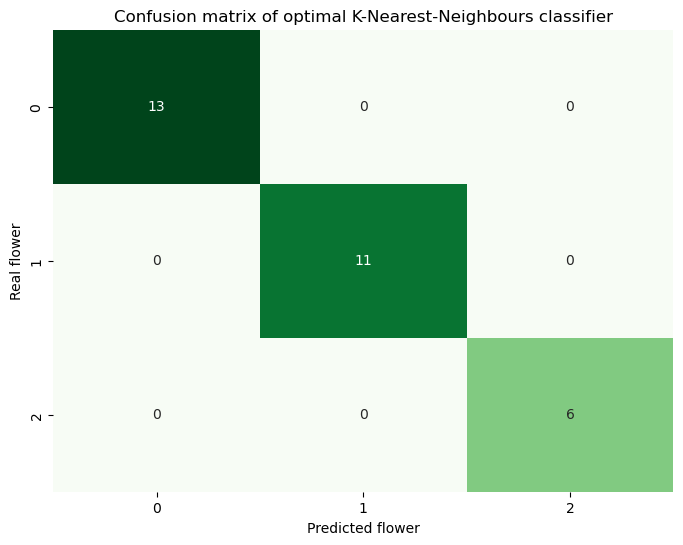

In [ ]:
# plot confusing matrix for the grid search best model using seaborn heatmap
# get the best model from grid search
model_best = grid.best_estimator_
# predict the labels for the test set
y_pred_best = model_best.predict(X_test)
# compute the confusion matrix
confusionmatrix = metrics.confusion_matrix(y_test, y_pred_best)
# plot the heatmap
plt.figure(figsize=(8, 6))
heatmap(confusionmatrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted flower')
plt.ylabel('Real flower')
plt.title('Confusion matrix of optimal K-Nearest-Neighbours classifier')
plt.show()
